In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/diabetes.csv')
df = df[df['Glucose'] > 0]

In [3]:
r_glucose_outcome = df['Glucose'].corr(df['Outcome'])
print(f"Correlation between Glucose and Outcome: {r_glucose_outcome:.3f}")

r_bmi_outcome = df['BMI'].corr(df['Outcome'])
print(f"Correlation between BMI and Outcome: {r_bmi_outcome:.3f}")

r_age_outcome = df['Age'].corr(df['Outcome'])
print(f"Correlation between Age and Outcome: {r_age_outcome:.3f}")

r_glucose_bmi = df['Glucose'].corr(df['BMI'])
print(f"Correlation between Glucose and BMI: {r_glucose_bmi:.3f}")

Correlation between Glucose and Outcome: 0.495
Correlation between BMI and Outcome: 0.289
Correlation between Age and Outcome: 0.235
Correlation between Glucose and BMI: 0.236


## Correlation Results — Interpretation

Glucose vs Outcome (r = 0.49): This is a moderatepositive correlation.
In plain English: patients with higher glucose readings tend to have higher probability of diabetes diagnosis. This makes clinical sense because diabetes is characterized by uncontrolled blood glucose levels.

BMI vs Outcome (r = 0.29): This is a weakly  positive correlation. Patients with higher BMI tend slightly more toward a diabetes diagnosis, but the relationship is not strong. This makes clinical sense because obesity is a known risk factor for Type 2 diabetes — excess adipose tissue contributes to insulin resistance — but BMI alone does not determine diagnosis, which is why the correlation is weak rather than strong.

Age vs Outcome (r = 0.23): This is also a weakly positive correlation. Older patients in this dataset are slightly more likely to have a diabetes diagnosis. This is clinically expected — Type 2 diabetes risk increases with age due to declining insulin sensitivity over time — but age is a background risk factor, not a direct marker, which explains the weak correlation.

Glucose vs BMI (r = 0.24): This is a weakly positive correlation. Patients with higher glucose also tend to have slightly higher BMI, but the relationship is weak. These two variables are both associated with diabetes risk but are measuring different things — one is a direct metabolic marker, the other is a body composition measure — so their correlation with each other is weaker than either's correlation with the actual outcome.

In [4]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.128135       0.140481      -0.082435   
Glucose                      0.128135  1.000000       0.158429       0.075178   
BloodPressure                0.140481  0.158429       1.000000       0.207590   
SkinThickness               -0.082435  0.075178       0.207590       1.000000   
Insulin                     -0.074960  0.331550       0.088731       0.440858   
BMI                          0.014874  0.235666       0.280781       0.391542   
DiabetesPedigreeFunction    -0.036063  0.137246       0.040426       0.183840   
Age                          0.542558  0.267136       0.239038      -0.114804   
Outcome                      0.218877  0.494650       0.063602       0.072382   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.074960  0.014874                 -0.036063   
Glucose                   0.331550  0.235

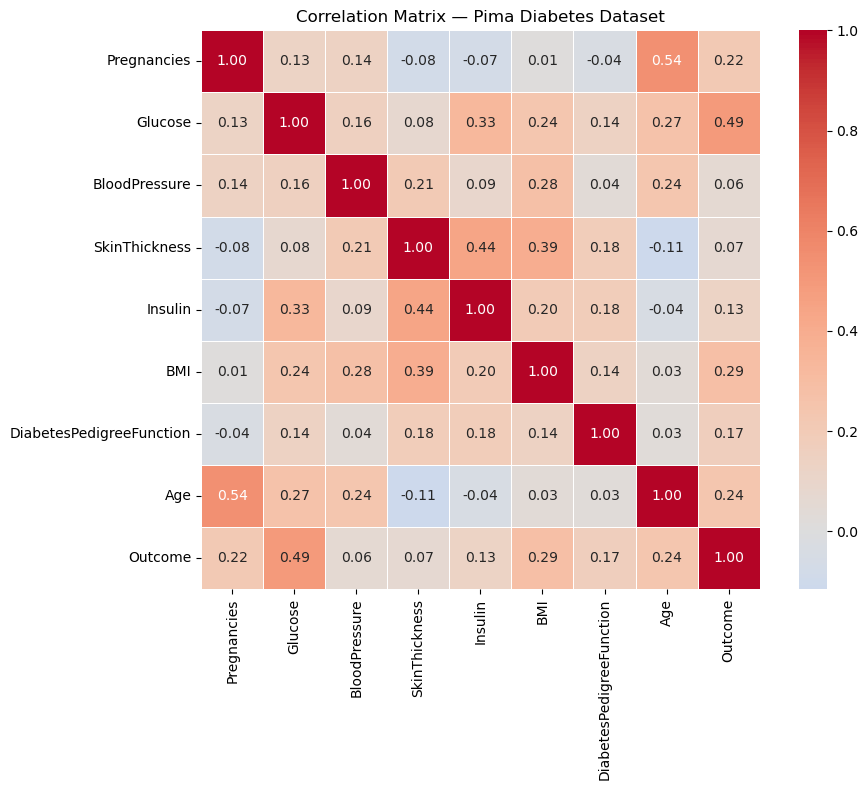

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Pima Diabetes Dataset')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150)
plt.show()

## Reading the Heatmap

The strongest positive correlation with Outcome is: Glucose, with r = 0.49. This is a moderate positive correlation — the strongest of all variables against the diabetes outcome.

**This makes clinical sense because:** glucose level is the most direct biochemical marker of diabetes — high blood glucose is literally the defining characteristic of the condition, so it naturally shows the strongest relationship with diagnosis outcome compared to indirect risk factors like BMI or age.

**The weakest correlation with Outcome is:** BloodPressure, with r = 0.06. This is essentially no meaningful relationship at all  blood pressure and diabetes diagnosis are nearly independent in this dataset, which makes some clinical sense since hypertension is a comorbidity of diabetes but not a direct diagnostic criterion.

**One correlation between two non-Outcome variables that surprised me:** Pregnancies and Age show r = 0.54 — the strongest correlation in the entire matrix outside the diagonal. This actually makes biological sense when you think about it — older women have had more years in which to accumulate pregnancies, so age and number of pregnancies naturally tend to increase together. It is not surprising once you reason through it, but it was not the first connection I would have thought to look for.

**One pair of variables I would NOT conclude have a causal relationship, even though they show correlation:** BMI and Outcome (r = 0.29). Even though higher BMI correlates moderately with diabetes diagnosis, I would not conclude that BMI causes diabetes. Both BMI and diabetes outcome are likely influenced by shared underlying factors — diet, physical activity, genetics, socioeconomic background — any of which could be driving both variables simultaneously. This connects directly to June's core lesson: correlation tells you two things move together, not which one is causing the other, or whether either is causing anything at all.

## Day 3 of July Complete

**The variable most strongly correlated with diabetes outcome was:** Glucose.

**In my own words, why correlation does not mean this variable causes diabetes:** A high glucose level is part of the definition of diabetes, not necessarily its cause. The underlying causes of Type 2 diabetes include insulin resistance, genetics, lifestyle, and obesity — these drive both the glucose elevation AND the diagnosis simultaneously. Glucose correlates strongly with outcome because it is a direct symptom and diagnostic criterion, not because elevated glucose alone causes the condition in isolation.

**One thing the heatmap showed me that the raw numbers alone did not:** The colour coding immediately drew my eye to the strongest relationships across the entire matrix at once — particularly the Pregnancies-Age correlation of 0.54, which I would not have noticed as quickly scanning a table of numbers. Visual patterns reveal structure that numerical tables hide.

**Confidence level today (honest, 1–10):** 6